# 🏅 CSCI 4341 – Big Data Analytics | Group Project
## Medal Outcome Prediction at the Paris 2024 Olympic Summer Games
### Replicating the Pipeline from:
> Taber, C.B., Sharma, S., Raval, M.S. et al. *A holistic approach to performance prediction in collegiate athletics: player, team, and conference perspectives.* **Scientific Reports**, 14, 1162 (2024). https://doi.org/10.1038/s41598-024-51658-8

---
**Dataset:** Paris 2024 Olympic Summer Games — Kaggle (piterfm)  
**Task:** Multi-class Classification — Predict medal outcome (Gold / Silver / Bronze / No Medal)  
**Pipeline:** Data Preprocessing → Feature Engineering → XGBoost + Random Forest → Evaluation

---

## 📦 SECTION 0 — Install & Import Libraries

In [ ]:
# Install required libraries (run once in Colab)
!pip install xgboost --quiet

In [ ]:
# Import Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# Preprocessing libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.utils            import resample

# Models libraries
from xgboost              import XGBClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Evaluation libraries
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay)

# Clustering & Stats libraries
from sklearn.cluster      import KMeans
from sklearn.preprocessing import MinMaxScaler
from scipy.stats           import chi2_contingency

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 📥 SECTION 1 — Load the Dataset
Dataset from: https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games  
Upload these CSV files to your drive: `athletes.csv`, `medals.csv`, `medallists.csv`, `events.csv`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set data path and load data from drive
DATA_PATH = '/content/drive/MyDrive/'

athletes   = pd.read_csv(DATA_PATH + 'athletes.csv')
medals     = pd.read_csv(DATA_PATH + 'medals.csv')
medallists = pd.read_csv(DATA_PATH + 'medallists.csv')
events     = pd.read_csv(DATA_PATH + 'events.csv')

print(f'athletes   : {athletes.shape}')
print(f'medals     : {medals.shape}')
print(f'medallists : {medallists.shape}')
print(f'events     : {events.shape}')
print('\nAthletes columns:', athletes.columns.tolist())
print('Medallists columns:', medallists.columns.tolist())

Mounted at /content/drive
athletes   : (11113, 36)
medals     : (1044, 13)
medallists : (2315, 21)
events     : (329, 5)

Athletes columns: ['code', 'current', 'name', 'name_short', 'name_tv', 'gender', 'function', 'country_code', 'country', 'country_long', 'nationality', 'nationality_long', 'nationality_code', 'height', 'weight', 'disciplines', 'events', 'birth_date', 'birth_place', 'birth_country', 'residence_place', 'residence_country', 'nickname', 'hobbies', 'occupation', 'education', 'family', 'lang', 'coach', 'reason', 'hero', 'influence', 'philosophy', 'sporting_relatives', 'ritual', 'other_sports']
Medallists columns: ['medal_date', 'medal_type', 'medal_code', 'name', 'gender', 'country_code', 'country', 'country_long', 'nationality_code', 'nationality', 'nationality_long', 'team', 'team_gender', 'discipline', 'event', 'event_type', 'url_event', 'birth_date', 'code_athlete', 'code_team', 'is_medallist']


In [ ]:
print('ATHLETES (first 5 rows)')
display(athletes.head(5))
print('\nMEDALLISTS (first 5 rows)')
display(medallists.head(5))
print('\nMEDALS (first 5 rows)')
display(medals.head(5))

ATHLETES (first 5 rows)


,code,current,name,name_short,name_tv,gender,function,country_code,country,country_long,...,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Father, Gevorg Aleksanyan","Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN
1,1532873,True,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,NaN,NaN,NaN,NaN,"""To become a good athlete, you first have to b...","Uncle, Roman Amoyan (wrestling), 2008 Olympic ...",NaN,NaN
2,1532874,True,GALSTYAN Slavik,GALSTYAN S,Slavik GALSTYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,Personal: Martin Alekhanyan (ARM).<br>National...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1532944,True,HARUTYUNYAN Arsen,HARUTYUNYAN A,Arsen HARUTYUNYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Diana (married October 2022). Daughter, ...",Armenian,National: Habetnak Kurghinyan,While doing karate he noticed wrestlers traini...,"Wrestler Armen Nazaryan (ARM, BUL), two-time O...",NaN,"“Nothing is impossible, set goals in front of ...",NaN,NaN,NaN
4,1532945,True,TEVANYAN Vazgen,TEVANYAN V,Vazgen TEVANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Sona (married November 2023)","Armenian, Russian",National: Habetnak Kurghinyan (ARM),“My family did not like wrestling very much. A...,NaN,NaN,NaN,NaN,NaN,NaN



MEDALLISTS (first 5 rows)


,medal_date,medal_type,medal_code,name,gender,country_code,country,country_long,nationality_code,nationality,...,team,team_gender,discipline,event,event_type,url_event,birth_date,code_athlete,code_team,is_medallist
0,2024-07-27,Gold Medal,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,2000-01-25,1903136,NaN,True
1,2024-07-27,Silver Medal,2.0,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1996-07-25,1923520,NaN,True
2,2024-07-27,Bronze Medal,3.0,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1994-09-15,1903147,NaN,True
3,2024-07-27,Gold Medal,1.0,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1992-07-07,1940173,NaN,True
4,2024-07-27,Silver Medal,2.0,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1998-11-14,1912525,NaN,True



MEDALS (first 5 rows)


,medal_type,medal_code,medal_date,name,gender,discipline,event,event_type,url_event,code,country_code,country,country_long
0,Gold Medal,1.0,2024-07-27,Remco EVENEPOEL,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903136,BEL,Belgium,Belgium
1,Silver Medal,2.0,2024-07-27,Filippo GANNA,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1923520,ITA,Italy,Italy
2,Bronze Medal,3.0,2024-07-27,Wout van AERT,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903147,BEL,Belgium,Belgium
3,Gold Medal,1.0,2024-07-27,Grace BROWN,W,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1940173,AUS,Australia,Australia
4,Silver Medal,2.0,2024-07-27,Anna HENDERSON,W,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1912525,GBR,Great Britain,Great Britain


---
## 🔍 SECTION 2 — Exploratory Data Analysis (EDA)

In [ ]:
#  Check data Information
print('Athletes Dataset Info')
athletes.info()
print('\nDescriptive Statistics')
display(athletes.describe())
print('\nMissing Values')
display(athletes.isnull().sum())

Athletes Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                11113 non-null  int64  
 1   current             11113 non-null  bool   
 2   name                11113 non-null  object 
 3   name_short          11110 non-null  object 
 4   name_tv             11110 non-null  object 
 5   gender              11113 non-null  object 
 6   function            11113 non-null  object 
 7   country_code        11113 non-null  object 
 8   country             11113 non-null  object 
 9   country_long        11113 non-null  object 
 10  nationality         11110 non-null  object 
 11  nationality_long    11110 non-null  object 
 12  nationality_code    11110 non-null  object 
 13  height              11110 non-null  float64
 14  weight              11108 non-null  float64
 15  disciplines         11113 non-n

,code,height,weight
count,1.111300e+04,11110.000000,11108.000000
mean,1.887418e+06,81.798830,2.211919
std,3.588006e+05,89.508247,13.109608
min,1.532872e+06,0.000000,0.000000
25%,1.888184e+06,0.000000,0.000000
50%,1.918840e+06,0.000000,0.000000
75%,1.948950e+06,177.000000,0.000000
max,9.460001e+06,222.000000,113.000000



Missing Values


,0
code,0
current,0
name,0
name_short,3
name_tv,3
gender,0
function,0
country_code,0
country,0
country_long,0


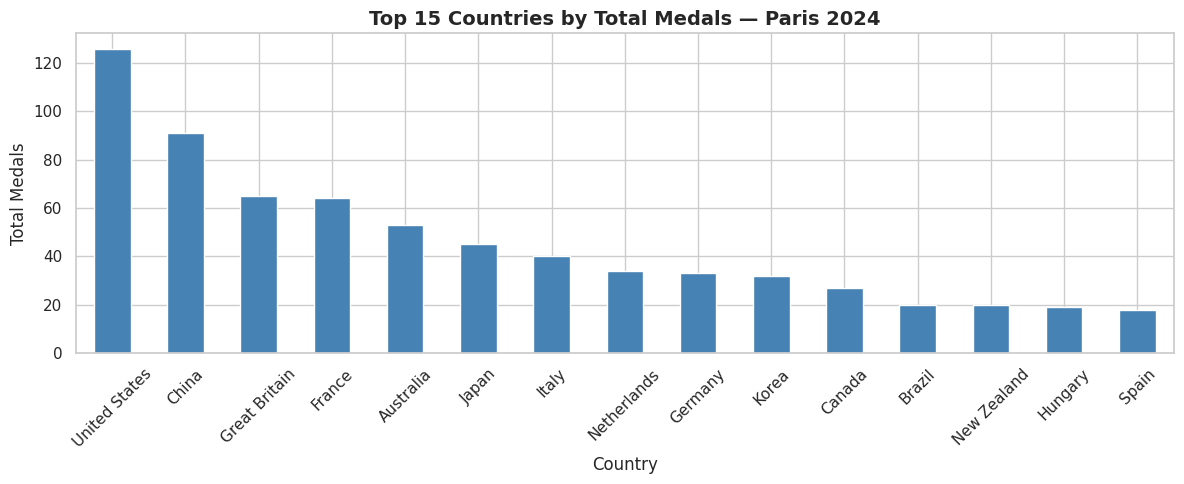

In [ ]:
# Top 15 Countries by Total Medals
# Detect country column name
country_medal_col = 'country' if 'country' in medals.columns else \
                    'country_code' if 'country_code' in medals.columns else \
                    medals.columns[1]

top_countries = (
    medals.groupby(country_medal_col)['medal_type']
    .count().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(12, 5))
top_countries.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Countries by Total Medals — Paris 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Total Medals')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('plot_01_top15_countries.png', dpi=150); plt.show()

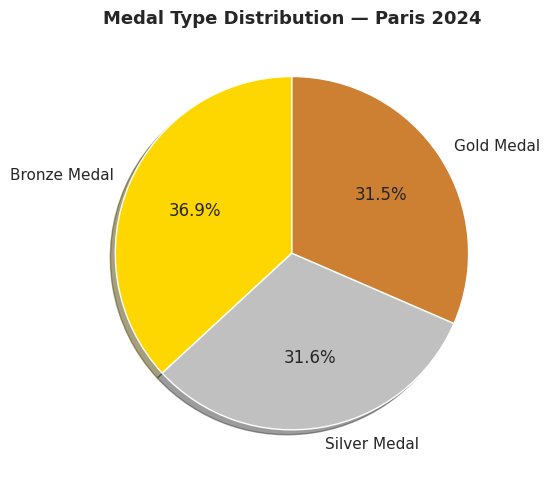

In [ ]:
# Medal Type Distribution
medal_counts = medals['medal_type'].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
medal_counts.plot(kind='pie', autopct='%1.1f%%',
                  colors=['#FFD700','#C0C0C0','#CD7F32'],
                  startangle=90, ax=ax, shadow=True)
ax.set_title('Medal Type Distribution — Paris 2024', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout(); plt.savefig('plot_02_medal_type_dist.png', dpi=150); plt.show()

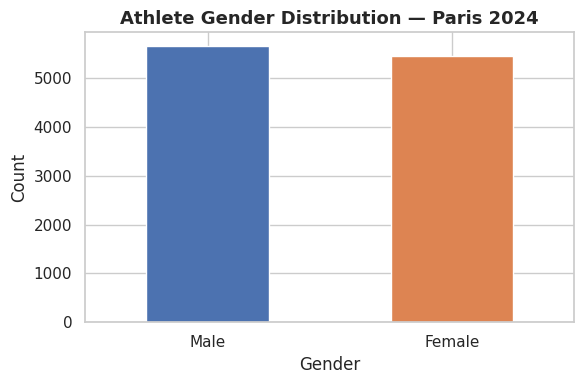

In [ ]:
# Gender Distribution
gender_col = 'gender' if 'gender' in athletes.columns else \
             'sex' if 'sex' in athletes.columns else None

if gender_col:
    gender_counts = athletes[gender_col].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    gender_counts.plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax, edgecolor='white')
    ax.set_title('Athlete Gender Distribution — Paris 2024', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gender'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout(); plt.savefig('plot_03_gender_dist.png', dpi=150); plt.show()
else:
    print('No gender column found. Columns:', athletes.columns.tolist())

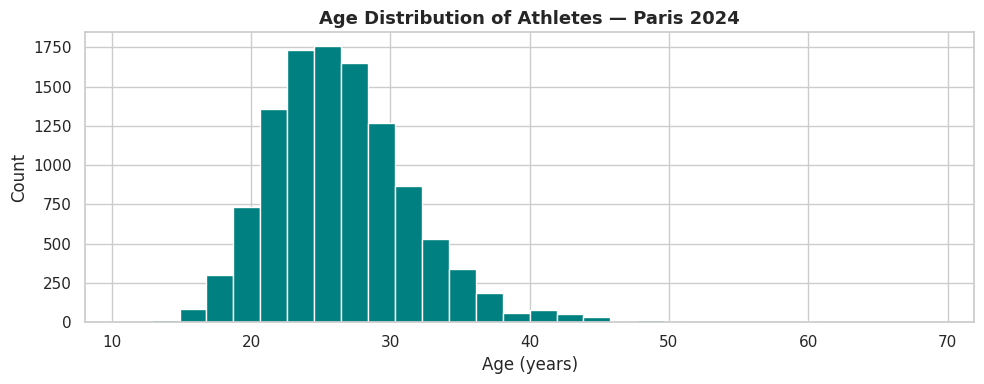

In [ ]:
# Age Distribution
if 'birth_date' in athletes.columns:
    athletes['birth_date'] = pd.to_datetime(athletes['birth_date'], errors='coerce')
    athletes['age'] = (pd.Timestamp('2024-07-26') - athletes['birth_date']).dt.days // 365

if 'age' in athletes.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    athletes['age'].dropna().plot(kind='hist', bins=30, color='teal', edgecolor='white', ax=ax)
    ax.set_title('Age Distribution of Athletes — Paris 2024', fontsize=13, fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('Count')
    plt.tight_layout(); plt.savefig('plot_04_age_dist.png', dpi=150); plt.show()
else:
    print('Age/birth_date column not found.')

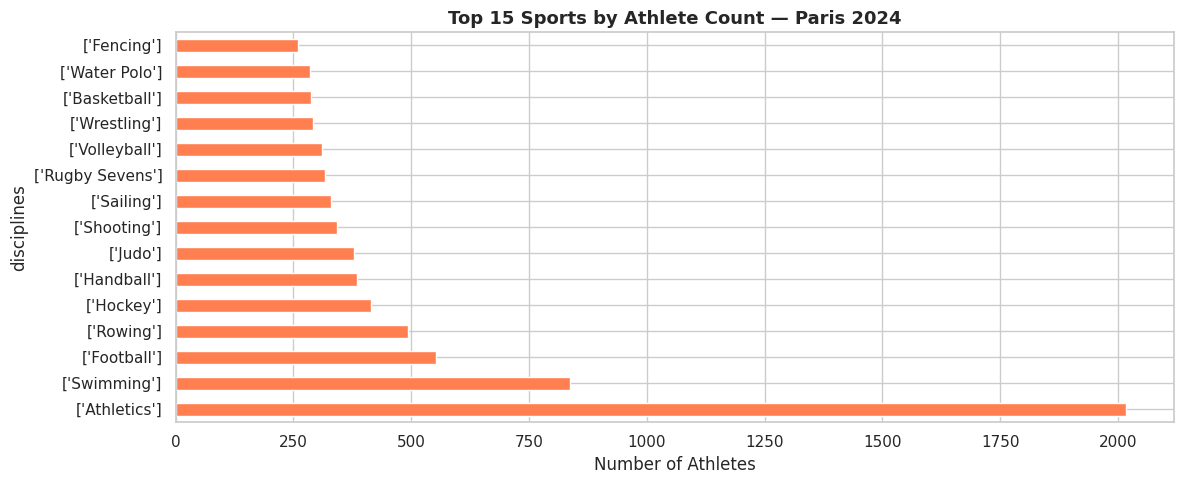

In [ ]:
# Top Sports by Athlete Count
sport_col = 'disciplines' if 'disciplines' in athletes.columns else \
            'discipline'  if 'discipline'  in athletes.columns else \
            'sport'       if 'sport'       in athletes.columns else None

if sport_col:
    top_sports = athletes[sport_col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_sports.plot(kind='barh', color='coral', edgecolor='white', ax=ax)
    ax.set_title(f'Top 15 Sports by Athlete Count — Paris 2024', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Athletes')
    plt.tight_layout(); plt.savefig('plot_05_top_sports.png', dpi=150); plt.show()
else:
    print('No sport/discipline column found. Columns:', athletes.columns.tolist())

---
## 🛠️ SECTION 3 — Data Preprocessing & Feature Engineering
**Paper alignment:** Taber et al. (2024) applied data balancing, feature selection, and label encoding before training.

In [ ]:
# Detect Key Column Names (robust to different dataset versions)
athlete_id_col = next((c for c in ['code','athlete_code','name'] if c in athletes.columns), athletes.columns[0])
medal_ath_col  = next((c for c in ['code','athlete_code','name'] if c in medallists.columns), medallists.columns[0])
country_col    = next((c for c in ['country','country_code'] if c in athletes.columns), None)
gender_col     = next((c for c in ['gender','sex'] if c in athletes.columns), None)
sport_col      = next((c for c in ['disciplines','discipline','sport'] if c in athletes.columns), None)

print(f'Athlete ID   : {athlete_id_col}')
print(f'Medal athlete: {medal_ath_col}')
print(f'Country      : {country_col}')
print(f'Gender       : {gender_col}')
print(f'Sport        : {sport_col}')

Athlete ID   : code
Medal athlete: name
Country      : country
Gender       : gender
Sport        : disciplines


In [ ]:
# Build Master Dataset
# Keep best medal per athlete (Gold > Silver > Bronze)
medal_order = {'Gold Medal': 0, 'Silver Medal': 1, 'Bronze Medal': 2}
med_lookup  = medallists.copy()
med_lookup['medal_rank'] = med_lookup['medal_type'].map(medal_order)

# Use 'code_athlete' for dropping duplicates and merging, as it's the actual athlete ID
# and convert its type to match 'code' in 'athletes'
med_lookup = (
    med_lookup.sort_values('medal_rank')
              .drop_duplicates(subset=['code_athlete'], keep='first')
              [['code_athlete', 'medal_type']]
)
# Rename 'code_athlete' to the standardized athlete_id_col ('code')
med_lookup.rename(columns={'code_athlete': athlete_id_col}, inplace=True)
# Ensure the merge key column has the same data type (int64) as in the athletes DataFrame
med_lookup[athlete_id_col] = med_lookup[athlete_id_col].astype(athletes[athlete_id_col].dtype)

df = athletes.merge(med_lookup, on=athlete_id_col, how='left')
df['medal_type'] = df['medal_type'].fillna('No Medal')

print(f'Master dataset: {df.shape}')
print('\nTarget class distribution:')
print(df['medal_type'].value_counts())

Master dataset: (11113, 38)

Target class distribution:
medal_type
No Medal        9059
Bronze Medal     693
Gold Medal       693
Silver Medal     668
Name: count, dtype: int64


In [ ]:
# Feature Engineering

# Age from birth_date
if 'birth_date' in df.columns:
    df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
    df['age'] = (pd.Timestamp('2024-07-26') - df['birth_date']).dt.days // 365

# Age bracket (for Q2 analysis)
if 'age' in df.columns:
    df['age_bracket'] = pd.cut(df['age'],
                               bins=[0, 18, 24, 30, 36, 100],
                               labels=['<18','18-24','25-30','31-36','37+'])

# Number of events entered per athlete
if sport_col:
    df['num_events_entered'] = df[sport_col].astype(str).apply(
        lambda x: len(x.split(',')) if pd.notna(x) else 1
    )

# Binary medal flag
df['won_medal'] = (df['medal_type'] != 'No Medal').astype(int)

# Country-level medal rate (country strength feature)
if country_col:
    c_medals   = df.groupby(country_col)['won_medal'].sum().rename('country_medal_count')
    c_athletes = df.groupby(country_col).size().rename('country_athlete_count')
    c_stats    = pd.concat([c_medals, c_athletes], axis=1)
    c_stats['country_medal_rate'] = c_stats['country_medal_count'] / c_stats['country_athlete_count']
    df = df.merge(c_stats.reset_index(), on=country_col, how='left')

print('Feature engineering complete.')
print('All columns now:', df.columns.tolist())

Feature engineering complete.
All columns now: ['code', 'current', 'name', 'name_short', 'name_tv', 'gender', 'function', 'country_code', 'country', 'country_long', 'nationality', 'nationality_long', 'nationality_code', 'height', 'weight', 'disciplines', 'events', 'birth_date', 'birth_place', 'birth_country', 'residence_place', 'residence_country', 'nickname', 'hobbies', 'occupation', 'education', 'family', 'lang', 'coach', 'reason', 'hero', 'influence', 'philosophy', 'sporting_relatives', 'ritual', 'other_sports', 'age', 'medal_type', 'age_bracket', 'num_events_entered', 'won_medal', 'country_medal_count', 'country_athlete_count', 'country_medal_rate']


In [ ]:
# Select Features
candidate_features = [
    'age', 'height', gender_col, country_col, sport_col,
    'num_events_entered', 'country_medal_count',
    'country_athlete_count', 'country_medal_rate'
]
FEATURES = [c for c in candidate_features if c is not None and c in df.columns]
TARGET   = 'medal_type'

print(f'Selected {len(FEATURES)} features: {FEATURES}')

Selected 9 features: ['age', 'height', 'gender', 'country', 'disciplines', 'num_events_entered', 'country_medal_count', 'country_athlete_count', 'country_medal_rate']


In [ ]:
# Handle Missing Values & Encode Categoricals
df_model = df[FEATURES + [TARGET]].copy()

# Fill numeric NaNs with median
for col in df_model.select_dtypes(include=[np.number]).columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Label-encode all categorical/object columns
le_dict = {}
for col in df_model.select_dtypes(include=['object','category']).columns:
    if col == TARGET: continue
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col]  = le

# Encode target
le_target = LabelEncoder()
df_model[TARGET] = le_target.fit_transform(df_model[TARGET])
class_names = le_target.classes_

print('Encoding complete.')
print(f'Target classes: {dict(enumerate(class_names))}')
print(f'Remaining NaN : {df_model.isnull().sum().sum()}')

Encoding complete.
Target classes: {0: 'Bronze Medal', 1: 'Gold Medal', 2: 'No Medal', 3: 'Silver Medal'}
Remaining NaN : 0


In [ ]:
# Class Balancing (Oversampling — matches Taber et al. 2024 approach)
print('Class distribution BEFORE balancing:')
print(df_model[TARGET].value_counts())

majority_class = df_model[TARGET].value_counts().idxmax()
majority_df    = df_model[df_model[TARGET] == majority_class]
balanced_dfs   = [majority_df]

for cls in df_model[TARGET].unique():
    if cls == majority_class: continue
    oversampled = resample(df_model[df_model[TARGET] == cls],
                           replace=True, n_samples=len(majority_df), random_state=42)
    balanced_dfs.append(oversampled)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print('\nClass distribution AFTER balancing:')
print(df_balanced[TARGET].value_counts())

X = df_balanced[FEATURES]
y = df_balanced[TARGET]

Class distribution BEFORE balancing:
medal_type
2    9059
0     693
1     693
3     668
Name: count, dtype: int64

Class distribution AFTER balancing:
medal_type
0    9059
1    9059
3    9059
2    9059
Name: count, dtype: int64


In [ ]:
# Train / Test Split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

Training set : (28988, 9)
Test set     : (7248, 9)


---
## 🤖 SECTION 4 — Model Training
**Paper alignment:** Taber et al. (2024) used XGBoost as the primary classifier + Random Forest for ensemble feature importance, with Logistic Regression as the baseline.

In [ ]:
# Baseline: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')
print(f'[Baseline] Logistic Regression — Accuracy: {acc_lr:.4f}  |  F1 (weighted): {f1_lr:.4f}')

[Baseline] Logistic Regression — Accuracy: 0.3852  |  F1 (weighted): 0.3631


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')
print(f'[Model 1]  Random Forest — Accuracy: {acc_rf:.4f}  |  F1 (weighted): {f1_rf:.4f}')

[Model 1]  Random Forest — Accuracy: 0.8237  |  F1 (weighted): 0.8232


In [ ]:
# XGBoost Classifier (Primary — Paper Replication)
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb, average='weighted')
print(f'\n[Model 2]  XGBoost (Primary)   — Accuracy: {acc_xgb:.4f}  |  F1 (weighted): {f1_xgb:.4f}')

[0]	validation_0-mlogloss:1.34366
[50]	validation_0-mlogloss:0.82375
[100]	validation_0-mlogloss:0.65252
[150]	validation_0-mlogloss:0.53967
[200]	validation_0-mlogloss:0.45749
[250]	validation_0-mlogloss:0.38852
[299]	validation_0-mlogloss:0.34112

[Model 2]  XGBoost (Primary)   — Accuracy: 0.9123  |  F1 (weighted): 0.9114


---
## 📊 SECTION 5 — Model Evaluation

    MODEL PERFORMANCE COMPARISON


,Model,Accuracy,F1 (weighted)
0,Logistic Regression (Baseline),0.3852,0.3631
1,Random Forest,0.8237,0.8232
2,XGBoost (Primary),0.9123,0.9114


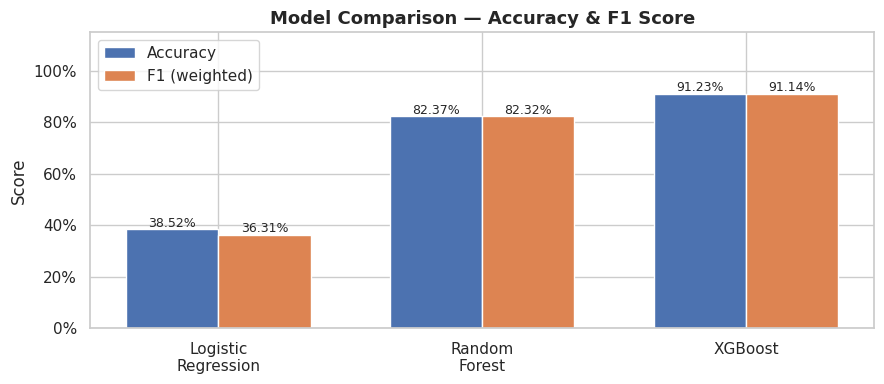

In [ ]:
# Model Comparison Table
results_df = pd.DataFrame({
    'Model'         : ['Logistic Regression (Baseline)', 'Random Forest', 'XGBoost (Primary)'],
    'Accuracy'      : [f'{acc_lr:.4f}', f'{acc_rf:.4f}', f'{acc_xgb:.4f}'],
    'F1 (weighted)' : [f'{f1_lr:.4f}',  f'{f1_rf:.4f}',  f'{f1_xgb:.4f}']
})
print('='*55)
print('    MODEL PERFORMANCE COMPARISON')
print('='*55)
display(results_df)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
x = np.arange(len(models)); w = 0.35
ax.bar(x-w/2, [acc_lr,acc_rf,acc_xgb], w, label='Accuracy',      color='#4C72B0', edgecolor='white')
ax.bar(x+w/2, [f1_lr, f1_rf, f1_xgb],  w, label='F1 (weighted)', color='#DD8452', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & F1 Score', fontsize=13, fontweight='bold')
ax.legend(); ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i,(a,f) in enumerate(zip([acc_lr,acc_rf,acc_xgb],[f1_lr,f1_rf,f1_xgb])):
    ax.text(i-w/2, a+0.01, f'{a:.2%}', ha='center', fontsize=9)
    ax.text(i+w/2, f+0.01, f'{f:.2%}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('plot_06_model_comparison.png', dpi=150); plt.show()

In [ ]:
# Classification Report (XGBoost, Random Forest and Logistic Regression
print('XGBoost — Full Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_xgb, target_names=class_names))
print('='*55)
print('Logistic Regression — Full Classification Report')
print(classification_report(y_test, y_pred_lr))
print('='*55)
print('Random Forest — Full Classification Report')
print(classification_report(y_test, y_pred_rf))

XGBoost — Full Classification Report
              precision    recall  f1-score   support

Bronze Medal       0.90      0.96      0.93      1812
  Gold Medal       0.89      0.93      0.91      1812
    No Medal       0.98      0.81      0.88      1812
Silver Medal       0.90      0.95      0.92      1812

    accuracy                           0.91      7248
   macro avg       0.92      0.91      0.91      7248
weighted avg       0.92      0.91      0.91      7248

Logistic Regression — Full Classification Report
              precision    recall  f1-score   support

           0       0.29      0.13      0.18      1812
           1       0.41      0.32      0.36      1812
           2       0.41      0.60      0.49      1812
           3       0.37      0.50      0.43      1812

    accuracy                           0.39      7248
   macro avg       0.37      0.39      0.36      7248
weighted avg       0.37      0.39      0.36      7248

Random Forest — Full Classification Report
 

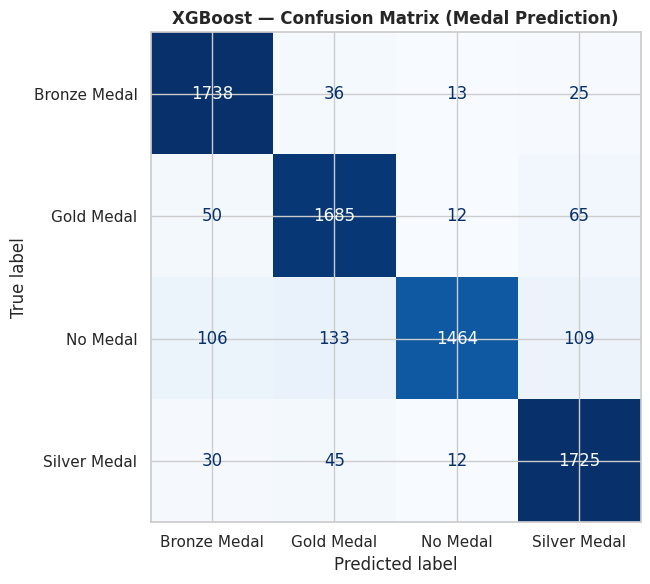

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('XGBoost — Confusion Matrix (Medal Prediction)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_07_confusion_matrix.png', dpi=150); plt.show()

XGBoost — 5-Fold Stratified Cross-Validation
  Fold 1: 0.9136
  Fold 2: 0.9135
  Fold 3: 0.9087
  Fold 4: 0.9154
  Fold 5: 0.9099
  Mean  : 0.9122 +/- 0.0025


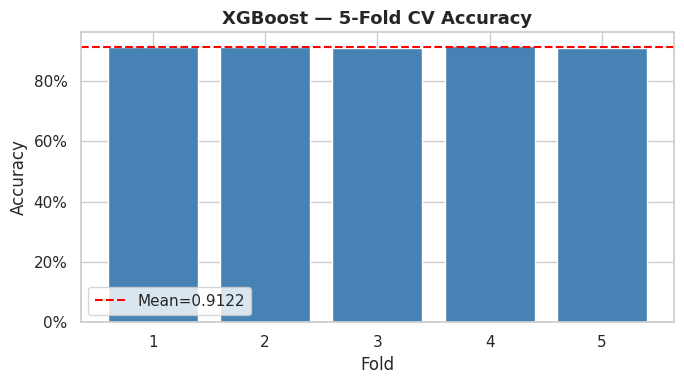

In [ ]:
# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('XGBoost — 5-Fold Stratified Cross-Validation')
print('='*45)
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1,6), cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('XGBoost — 5-Fold CV Accuracy', fontsize=13, fontweight='bold')
ax.legend(); ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout(); plt.savefig('plot_08_cross_validation.png', dpi=150); plt.show()

In [ ]:
print("X_train" in globals())
print("X_test" in globals())
print("y_train" in globals())
print("y_test" in globals())

True
True
True
True


In [ ]:
# Split calibration data
X_train_cp, X_cal, y_train_cp, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# Train model
xgb.fit(X_train_cp, y_train_cp)

# Calibration probabilities
cal_probs = xgb.predict_proba(X_cal)

scores = 1 - cal_probs[np.arange(len(y_cal)), y_cal]

alpha = 0.05
q = np.quantile(scores, 1-alpha)

# Test probabilities
test_probs = xgb.predict_proba(X_test)

prediction_sets = test_probs >= (1-q)

coverage = np.mean([
    prediction_sets[i, y_test.iloc[i]]
    for i in range(len(y_test))
])

avg_set_size = prediction_sets.sum(axis=1).mean()

print("Coverage:", coverage)
print("Average Prediction Set Size:", avg_set_size)

Coverage: 0.9431567328918322
Average Prediction Set Size: 1.1041666666666667


SPLIT CONFORMAL PREDICTION RESULTS


,Metric,Value
0,Confidence Level,95%
1,Coverage,0.9432
2,Average Prediction Set Size,1.10


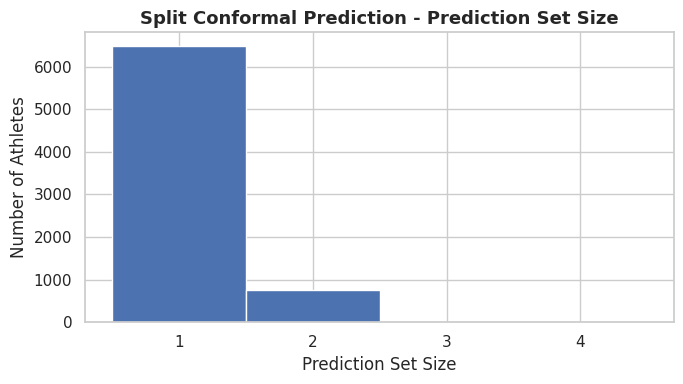

In [ ]:
cp_results = pd.DataFrame({
    'Metric': [
        'Confidence Level',
        'Coverage',
        'Average Prediction Set Size'
    ],
    'Value': [
        '95%',
        f'{coverage:.4f}',
        f'{avg_set_size:.2f}'
    ]
})

print('SPLIT CONFORMAL PREDICTION RESULTS')
display(cp_results)

set_sizes = prediction_sets.sum(axis=1)

fig, ax = plt.subplots(figsize=(7,4))

ax.hist(
    set_sizes,
    bins=np.arange(1,6)-0.5,
    edgecolor='white',
    color='#4C72B0'
)

ax.set_xticks(range(1,5))
ax.set_xlabel('Prediction Set Size')
ax.set_ylabel('Number of Athletes')
ax.set_title('Split Conformal Prediction - Prediction Set Size',
             fontsize=13,
             fontweight='bold')

plt.tight_layout()
plt.savefig('plot_09_conformal_prediction.png', dpi=150)
plt.show()

---
## 🔎 SECTION 6 — Feature Importance (Ensemble Method — Paper Replication)

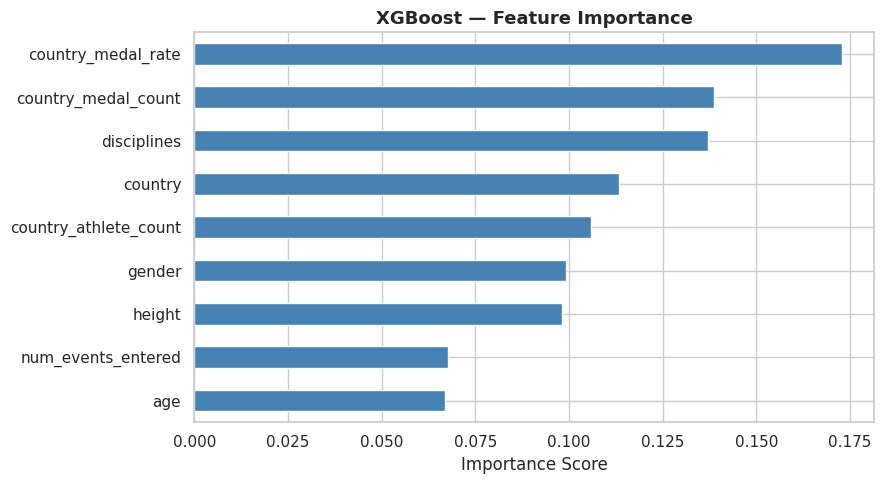

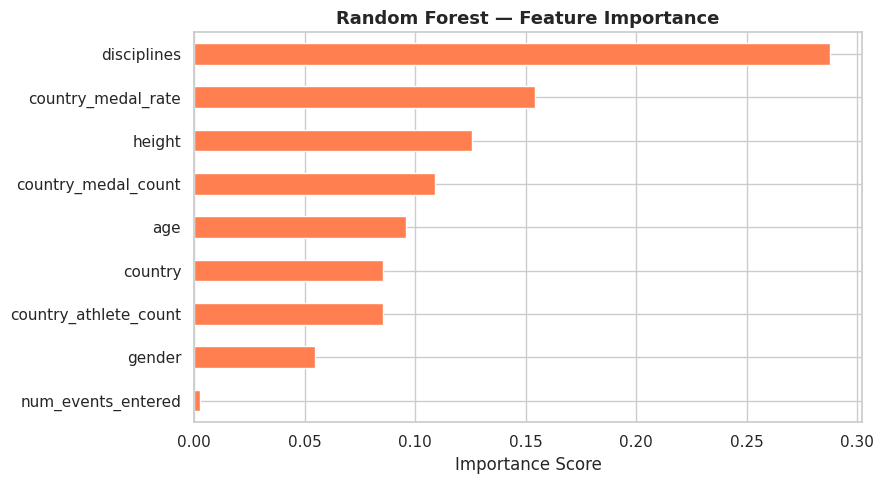

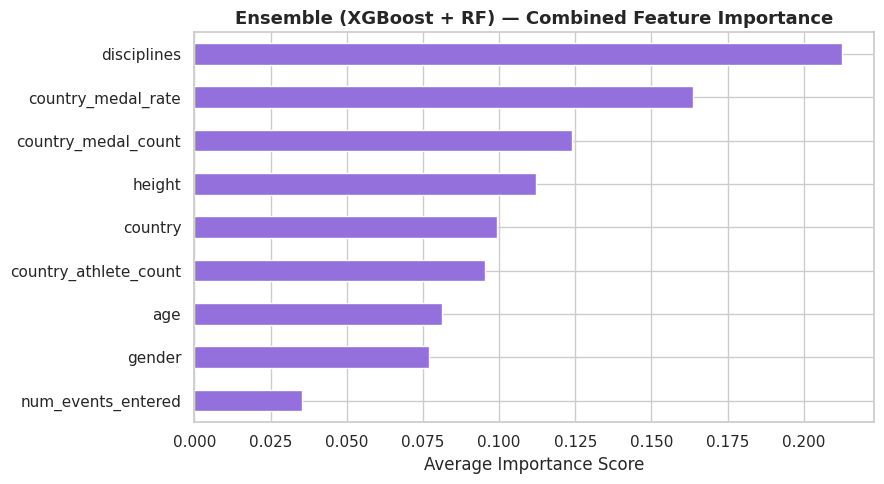

In [ ]:
# XGBoost Feature Importance
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9,5))
xgb_imp.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.savefig('plot_09_xgb_importance.png', dpi=150); plt.show()

# Random Forest Feature Importance
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9,5))
rf_imp.plot(kind='barh', color='coral', edgecolor='white', ax=ax)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.savefig('plot_10_rf_importance.png', dpi=150); plt.show()

# Ensemble (XGBoost + RF) — Paper Method
ensemble_imp = ((xgb_imp + rf_imp) / 2).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9,5))
ensemble_imp.plot(kind='barh', color='mediumpurple', edgecolor='white', ax=ax)
ax.set_title('Ensemble (XGBoost + RF) — Combined Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Importance Score')
plt.tight_layout(); plt.savefig('plot_11_ensemble_importance.png', dpi=150); plt.show()

---
## ❓ SECTION 7 — Research Questions Analysis

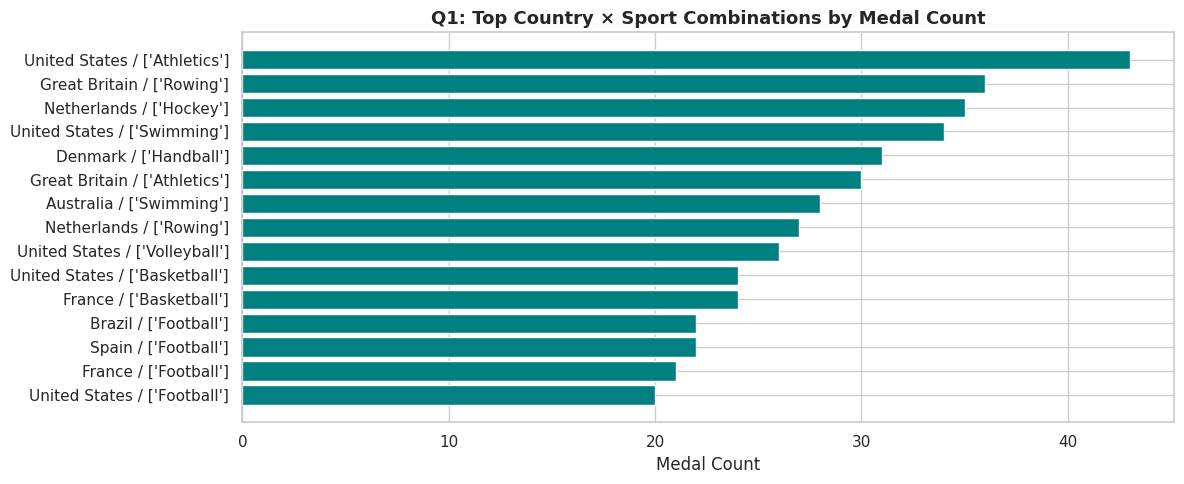

In [ ]:
# Q1 (Diagnostic): Country × Sport × Medal Count
if sport_col and country_col:
    q1 = (
        df[df['medal_type'] != 'No Medal']
        .groupby([country_col, sport_col])['medal_type'].count()
        .reset_index(name='medal_count')
        .sort_values('medal_count', ascending=False).head(15)
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = q1[country_col] + ' / ' + q1[sport_col]
    ax.barh(labels, q1['medal_count'], color='teal', edgecolor='white')
    ax.set_title('Q1: Top Country × Sport Combinations by Medal Count', fontsize=13, fontweight='bold')
    ax.set_xlabel('Medal Count'); ax.invert_yaxis()
    plt.tight_layout(); plt.savefig('plot_Q1_country_sport.png', dpi=150); plt.show()

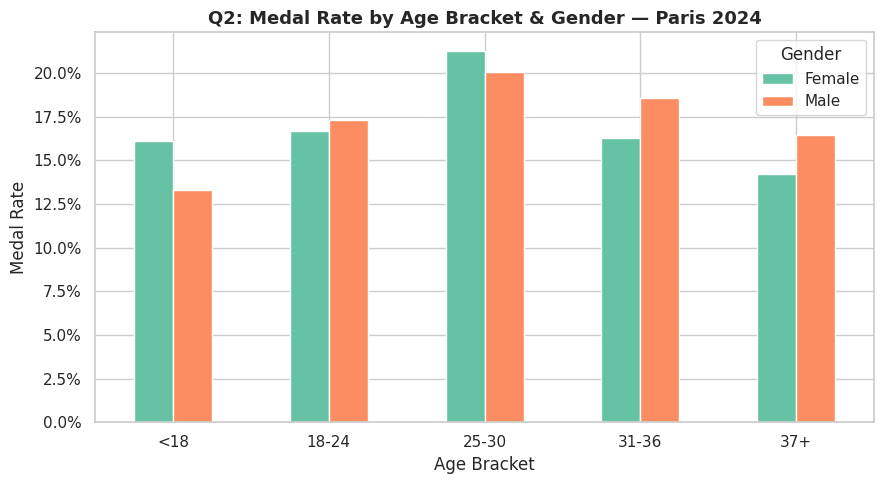

In [ ]:
# Q2 (Diagnostic): Age Bracket × Gender → Medal Rate
if 'age_bracket' in df.columns and gender_col:
    q2 = df.groupby(['age_bracket', gender_col])['won_medal'].mean().reset_index(name='medal_rate')
    q2_pivot = q2.pivot(index='age_bracket', columns=gender_col, values='medal_rate')
    fig, ax = plt.subplots(figsize=(9, 5))
    q2_pivot.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title('Q2: Medal Rate by Age Bracket & Gender — Paris 2024', fontsize=13, fontweight='bold')
    ax.set_xlabel('Age Bracket'); ax.set_ylabel('Medal Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis='x', rotation=0); ax.legend(title='Gender')
    plt.tight_layout(); plt.savefig('plot_Q2_age_gender.png', dpi=150); plt.show()

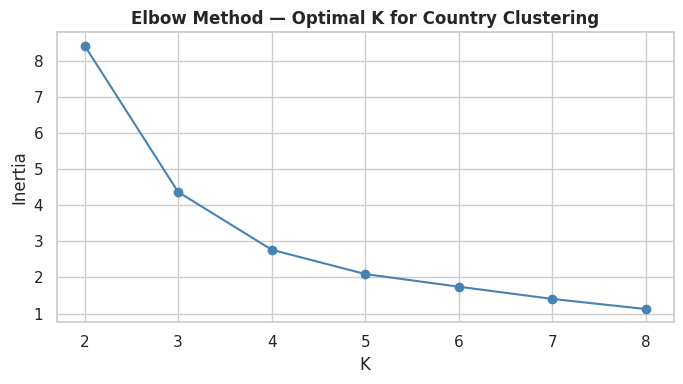

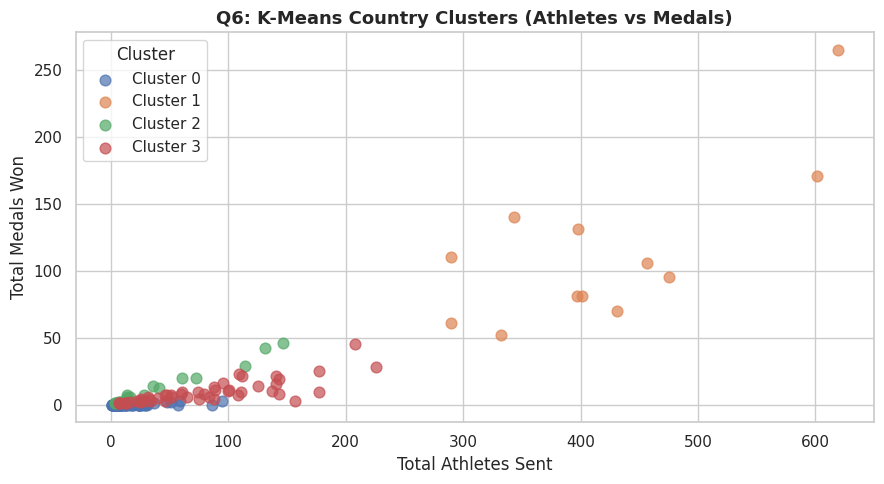

,country,total_athletes,total_medals,medal_rate,cluster
195,United States,619,265,0.428110,1
68,France,601,171,0.284526,1
74,Great Britain,343,140,0.408163,1
39,China,398,131,0.329146,1
133,Netherlands,290,110,0.379310,1
72,Germany,457,106,0.231947,1
11,Australia,475,95,0.200000,1
172,Spain,401,81,0.201995,1
93,Italy,397,81,0.204030,1
95,Japan,431,70,0.162413,1


In [ ]:
# Q6 (Clustering): K-Means — Country Olympic Program Profiles
if country_col:
    cluster_df = df.groupby(country_col).agg(
        total_athletes=( athlete_id_col, 'count'),
        total_medals  =('won_medal', 'sum'),
        medal_rate    =('won_medal', 'mean')
    ).reset_index()

    X_cl = MinMaxScaler().fit_transform(cluster_df[['total_athletes','total_medals','medal_rate']])

    # Elbow method
    inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cl).inertia_ for k in range(2,9)]
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(range(2,9), inertias, marker='o', color='steelblue')
    ax.set_title('Elbow Method — Optimal K for Country Clustering', fontsize=12, fontweight='bold')
    ax.set_xlabel('K'); ax.set_ylabel('Inertia')
    plt.tight_layout(); plt.savefig('plot_Q6_elbow.png', dpi=150); plt.show()

    # K=4 final clustering
    cluster_df['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_cl)
    fig, ax = plt.subplots(figsize=(9,5))
    colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
    for c in range(4):
        sub = cluster_df[cluster_df['cluster']==c]
        ax.scatter(sub['total_athletes'], sub['total_medals'],
                   label=f'Cluster {c}', s=60, alpha=0.7, color=colors[c])
    ax.set_title('Q6: K-Means Country Clusters (Athletes vs Medals)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Total Athletes Sent'); ax.set_ylabel('Total Medals Won')
    ax.legend(title='Cluster')
    plt.tight_layout(); plt.savefig('plot_Q6_clusters.png', dpi=150); plt.show()
    display(cluster_df.sort_values('total_medals', ascending=False).head(10))

In [ ]:
# Q8 (Inferential): Chi-Square Test — Country × Medal Type Independence
if country_col:
    contingency = pd.crosstab(df[country_col], df['medal_type'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print('Chi-Square Test: Country vs Medal Type')
    print('='*45)
    print(f'  Chi2 statistic     : {chi2:.4f}')
    print(f'  p-value            : {p:.6e}')
    print(f'  Degrees of freedom : {dof}')
    if p < 0.05:
        print('  RESULT: Reject H0 — Country and medal type are NOT independent (p < 0.05)')
    else:
        print('  RESULT: Fail to reject H0 (p >= 0.05)')

Chi-Square Test: Country vs Medal Type
  Chi2 statistic     : 1805.8845
  p-value            : 2.111375e-117
  Degrees of freedom : 615
  RESULT: Reject H0 — Country and medal type are NOT independent (p < 0.05)


France medal rate          : 0.2845 (28.45%)
All other countries rate   : 0.1791 (17.91%)
Ratio (France vs Others)   : 1.59x


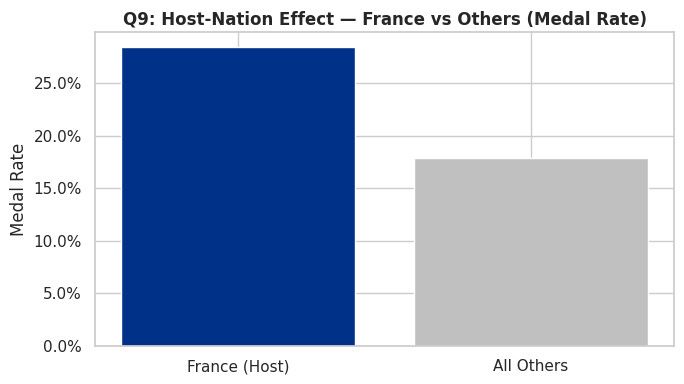

In [ ]:
# Q9 (Inferential): Host-Nation Effect — France Medal Distribution
if country_col:
    france_code = 'France' if 'France' in df[country_col].values else \
                  'FRA'    if 'FRA'    in df[country_col].values else None
    if france_code:
        france_df = df[df[country_col] == france_code]
        others_df = df[df[country_col] != france_code]
        france_rate = france_df['won_medal'].mean()
        others_rate = others_df['won_medal'].mean()
        print(f'France medal rate          : {france_rate:.4f} ({france_rate*100:.2f}%)')
        print(f'All other countries rate   : {others_rate:.4f} ({others_rate*100:.2f}%)')
        print(f'Ratio (France vs Others)   : {france_rate/others_rate:.2f}x')

        fig, ax = plt.subplots(figsize=(7,4))
        ax.bar(['France (Host)', 'All Others'], [france_rate, others_rate],
               color=['#003189','#C0C0C0'], edgecolor='white')
        ax.set_title('Q9: Host-Nation Effect — France vs Others (Medal Rate)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Medal Rate')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        plt.tight_layout(); plt.savefig('plot_Q9_host_effect.png', dpi=150); plt.show()
    else:
        print('France not found. Check country values:', df[country_col].unique()[:10])

---
## 📋 SECTION 8 — Final Summary & Export

In [ ]:
print('='*62)
print('    FINAL RESULTS — CSCI 4341 Big Data Analytics Project')
print('    Paris 2024 Olympic Summer Games — Medal Prediction')
print('='*62)
print(f'  Paper Replicated : Taber et al. (2024) — Scientific Reports')
print(f'  Dataset          : Paris 2024 Olympics (Kaggle, piterfm)')
print(f'  Total Athletes   : {len(athletes)}')
print(f'  Features Used    : {len(FEATURES)} features')
print(f'  ML Task          : Multi-class Classification (4 classes)')
print(f'  Target Classes   : {list(class_names)}')
print()
print(f'  [Baseline] Logistic Regression : Acc={acc_lr:.4f} | F1={f1_lr:.4f}')
print(f'  [Model 1]  Random Forest       : Acc={acc_rf:.4f} | F1={f1_rf:.4f}')
print(f'  [Model 2]  XGBoost (Primary)   : Acc={acc_xgb:.4f} | F1={f1_xgb:.4f}')
print(f'  [CV]       XGBoost 5-Fold      : Mean={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('='*62)

    FINAL RESULTS — CSCI 4341 Big Data Analytics Project
    Paris 2024 Olympic Summer Games — Medal Prediction
  Paper Replicated : Taber et al. (2024) — Scientific Reports
  Dataset          : Paris 2024 Olympics (Kaggle, piterfm)
  Total Athletes   : 11113
  Features Used    : 9 features
  ML Task          : Multi-class Classification (4 classes)
  Target Classes   : ['Bronze Medal', 'Gold Medal', 'No Medal', 'Silver Medal']

  [Baseline] Logistic Regression : Acc=0.3852 | F1=0.3631
  [Model 1]  Random Forest       : Acc=0.8237 | F1=0.8232
  [Model 2]  XGBoost (Primary)   : Acc=0.9123 | F1=0.9114
  [CV]       XGBoost 5-Fold      : Mean=0.9122 +/- 0.0025


In [ ]:
# Export predictions & summary
df_export = df[FEATURES + ['medal_type']].dropna().copy()
valid_mask = df_export['medal_type'].isin(class_names)
df_export  = df_export[valid_mask]

X_all = df_export[FEATURES].copy()
for col in X_all.select_dtypes(include=['object','category']).columns:
    if col in le_dict:
        X_all[col] = X_all[col].astype(str)
        known_classes = set(le_dict[col].classes_)
        X_all[col] = X_all[col].apply(lambda x: x if x in known_classes else le_dict[col].classes_[0])
        X_all[col] = le_dict[col].transform(X_all[col])

df_export['xgb_prediction']  = le_target.inverse_transform(xgb.predict(X_all))
df_export['xgb_probability'] = xgb.predict_proba(X_all).max(axis=1).round(4)
df_export.to_csv('paris2024_predictions.csv', index=False)
results_df.to_csv('model_performance_summary.csv', index=False)

print('Exported files:')
print('  paris2024_predictions.csv     — Predictions for all athletes')
print('  model_performance_summary.csv — Model comparison table')
print('  plot_*.png                    — All visualisation plots')
print()
print('Pipeline complete! Replicated from Taber et al. (2024) Scientific Reports.')

Exported files:
  paris2024_predictions.csv     — Predictions for all athletes
  model_performance_summary.csv — Model comparison table
  plot_*.png                    — All visualisation plots

Pipeline complete! Replicated from Taber et al. (2024) Scientific Reports.
